# Latent Prediction vs Pixel Prediction - Visual Experiments

> **Goal:** Identify when a representation-space target removes nuisance uncertainty, when pixel losses average incompatible observations, and what detail is lost as targets become more abstract.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Irreducible nuisance error** | Why does pixel loss grow on unpredictable detail? |
| 2 | **Conditional averaging** | Why can the MSE-optimal pixel output look unlike any valid target? |
| 3 | **Metric alignment** | Why can latent distance retrieve semantics that pixel distance misses? |
| 4 | **Abstraction trade-off** | What is gained and lost as the target filters more detail? |

---
**Linked theory:** [research/09-latent-vs-pixel-prediction.md](../research/09-latent-vs-pixel-prediction.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
})

def normalized(array):
    minimum = array.min()
    maximum = array.max()
    return (array - minimum) / max(maximum - minimum, 1e-12)

def lowpass(images, radius):
    height, width = images.shape[-2:]
    fy = np.fft.fftfreq(height)[:, None]
    fx = np.fft.fftfreq(width)[None, :]
    mask = np.sqrt(fx ** 2 + fy ** 2) <= radius
    spectrum = np.fft.fft2(images, axes=(-2, -1))
    return np.fft.ifft2(spectrum * mask, axes=(-2, -1)).real

---
## Experiment 1: Irreducible nuisance error

**Question:** Why can a perfect semantic predictor still have high pixel loss?

The context determines a smooth signal exactly, but each target contains an independent texture realization. The best deterministic pixel predictor recovers the smooth signal and cannot predict the random texture.

In [2]:
rng_exp1 = np.random.default_rng(4)
positions_exp1 = np.linspace(0, 2 * np.pi, 180)
semantic_exp1 = np.sin(positions_exp1) + 0.35 * np.sin(2 * positions_exp1 + 0.5)
noise_levels_exp1 = np.linspace(0, 1.25, 28)
trials_exp1 = 500
pixel_risk_exp1 = []
latent_risk_exp1 = []

for noise_level in noise_levels_exp1:
    noise = rng_exp1.normal(0, noise_level, size=(trials_exp1, len(positions_exp1)))
    targets = semantic_exp1[None, :] + noise
    pixel_prediction = semantic_exp1[None, :]
    pixel_risk_exp1.append(np.mean((pixel_prediction - targets) ** 2))

    target_latent = np.array([1.0, 0.35, 0.5])
    predicted_latent = target_latent.copy()
    latent_risk_exp1.append(np.mean((predicted_latent - target_latent) ** 2))

example_noise_exp1 = rng_exp1.normal(0, 0.75, size=(4, len(positions_exp1)))
example_targets_exp1 = semantic_exp1[None, :] + example_noise_exp1

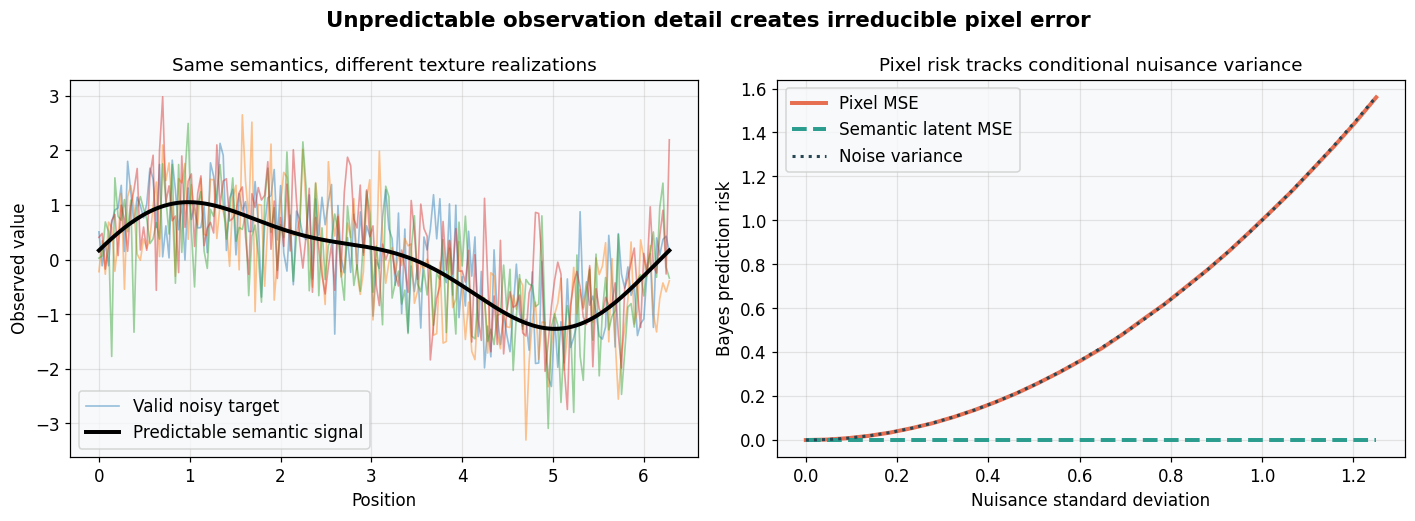

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle('Unpredictable observation detail creates irreducible pixel error', fontsize=14, fontweight='bold')

ax = axes[0]
for index, target in enumerate(example_targets_exp1):
    ax.plot(positions_exp1, target, alpha=0.45, linewidth=1.1, label='Valid noisy target' if index == 0 else None)
ax.plot(positions_exp1, semantic_exp1, color='black', linewidth=2.6, label='Predictable semantic signal')
ax.set_xlabel('Position')
ax.set_ylabel('Observed value')
ax.set_title('Same semantics, different texture realizations')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(noise_levels_exp1, pixel_risk_exp1, color='#e76f51', linewidth=2.6, label='Pixel MSE')
ax.plot(noise_levels_exp1, latent_risk_exp1, '--', color='#2a9d8f', linewidth=2.6, label='Semantic latent MSE')
ax.plot(noise_levels_exp1, noise_levels_exp1 ** 2, ':', color='#264653', linewidth=2, label='Noise variance')
ax.set_xlabel('Nuisance standard deviation')
ax.set_ylabel('Bayes prediction risk')
ax.set_title('Pixel risk tracks conditional nuisance variance')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Pixel MSE rises with noise variance even though the predictable signal is recovered exactly; the idealized semantic target is unaffected.
2. **Why it looks this way:** A pixel metric scores every random realization. A target encoder can map all realizations to the same semantic equivalence class.
3. **Key takeaway:** Latent prediction helps when it removes uncertainty that is irrelevant to the intended representation.

---
## Experiment 2: Conditional averaging under pixel MSE

**Question:** Why can the optimal deterministic pixel prediction be visually invalid?

The hidden object has one of two equally likely checkerboard phases. Both observations mean the same thing semantically, but their pixel-wise conditional mean cancels.

In [4]:
size_exp2 = 40
yy_exp2, xx_exp2 = np.mgrid[:size_exp2, :size_exp2]
circle_exp2 = (xx_exp2 - 19.5) ** 2 + (yy_exp2 - 19.5) ** 2 <= 13 ** 2
checker_exp2 = ((xx_exp2 // 4 + yy_exp2 // 4) % 2) * 2 - 1

mode_a_exp2 = circle_exp2 * checker_exp2
mode_b_exp2 = -mode_a_exp2
pixel_mean_exp2 = 0.5 * (mode_a_exp2 + mode_b_exp2)

latent_a_exp2 = np.array([1.0, 13.0, 19.5, 19.5])
latent_b_exp2 = latent_a_exp2.copy()
latent_mean_exp2 = 0.5 * (latent_a_exp2 + latent_b_exp2)

pixel_mode_error_exp2 = 0.5 * (
    np.mean((pixel_mean_exp2 - mode_a_exp2) ** 2)
    + np.mean((pixel_mean_exp2 - mode_b_exp2) ** 2)
)
latent_mode_error_exp2 = 0.5 * (
    np.mean((latent_mean_exp2 - latent_a_exp2) ** 2)
    + np.mean((latent_mean_exp2 - latent_b_exp2) ** 2)
)

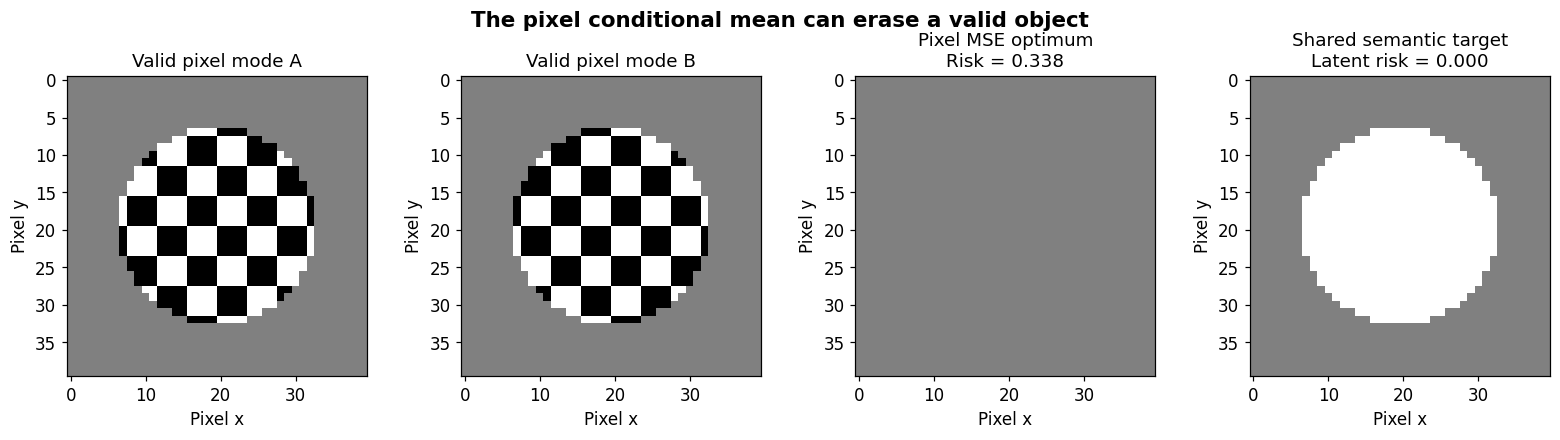

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14.5, 3.8))
fig.suptitle('The pixel conditional mean can erase a valid object', fontsize=14, fontweight='bold')

panels = [
    (mode_a_exp2, 'Valid pixel mode A'),
    (mode_b_exp2, 'Valid pixel mode B'),
    (pixel_mean_exp2, f'Pixel MSE optimum\nRisk = {pixel_mode_error_exp2:.3f}'),
    (circle_exp2.astype(float), f'Shared semantic target\nLatent risk = {latent_mode_error_exp2:.3f}'),
]

for ax, (image, title) in zip(axes, panels):
    ax.imshow(image, cmap='gray', vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Pixel x')
    ax.set_ylabel('Pixel y')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Averaging opposite checker phases produces a blank image, while both modes share the same object-level latent description.
2. **Why it looks this way:** Squared error selects the conditional pixel mean. A representation that treats texture phase as nuisance collapses the two observation modes before prediction.
3. **Key takeaway:** Abstraction can remove nuisance multimodality, but it cannot remove genuinely different semantic futures.

---
## Experiment 3: Pixel distance and semantic distance rank neighbors differently

**Question:** Why can latent prediction create more useful geometry for transfer?

We construct images whose high-amplitude texture can dominate Euclidean pixel distance. An idealized semantic encoder represents shape identity and ignores texture phase.

In [6]:
size_exp3 = 36
yy_exp3, xx_exp3 = np.mgrid[:size_exp3, :size_exp3]
circle_exp3 = ((xx_exp3 - 17.5) ** 2 + (yy_exp3 - 17.5) ** 2 <= 10.5 ** 2).astype(float)
square_exp3 = ((np.abs(xx_exp3 - 17.5) <= 9) & (np.abs(yy_exp3 - 17.5) <= 9)).astype(float)
triangle_exp3 = ((yy_exp3 >= 8) & (yy_exp3 <= 28) & (np.abs(xx_exp3 - 17.5) <= (yy_exp3 - 8) * 0.48)).astype(float)

vertical_exp3 = np.sin(2 * np.pi * xx_exp3 / 5)
horizontal_exp3 = np.sin(2 * np.pi * yy_exp3 / 5)
diagonal_exp3 = np.sin(2 * np.pi * (xx_exp3 + yy_exp3) / 7)

def render_exp3(shape, texture):
    return 0.35 * shape + 0.9 * texture

query_exp3 = render_exp3(circle_exp3, vertical_exp3)
candidate_images_exp3 = np.stack([
    render_exp3(square_exp3, vertical_exp3),
    render_exp3(triangle_exp3, vertical_exp3),
    render_exp3(circle_exp3, horizontal_exp3),
    render_exp3(circle_exp3, diagonal_exp3),
    render_exp3(square_exp3, horizontal_exp3),
])
candidate_names_exp3 = ['square / vertical', 'triangle / vertical', 'circle / horizontal', 'circle / diagonal', 'square / horizontal']

pixel_distances_exp3 = np.mean((candidate_images_exp3 - query_exp3[None, ...]) ** 2, axis=(1, 2))
query_latent_exp3 = np.array([1.0, 0.0, 0.0])
candidate_latents_exp3 = np.array([
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [1.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
])
latent_distances_exp3 = np.linalg.norm(candidate_latents_exp3 - query_latent_exp3, axis=1)
pixel_neighbor_exp3 = np.argmin(pixel_distances_exp3)
latent_neighbor_exp3 = np.argmin(latent_distances_exp3)

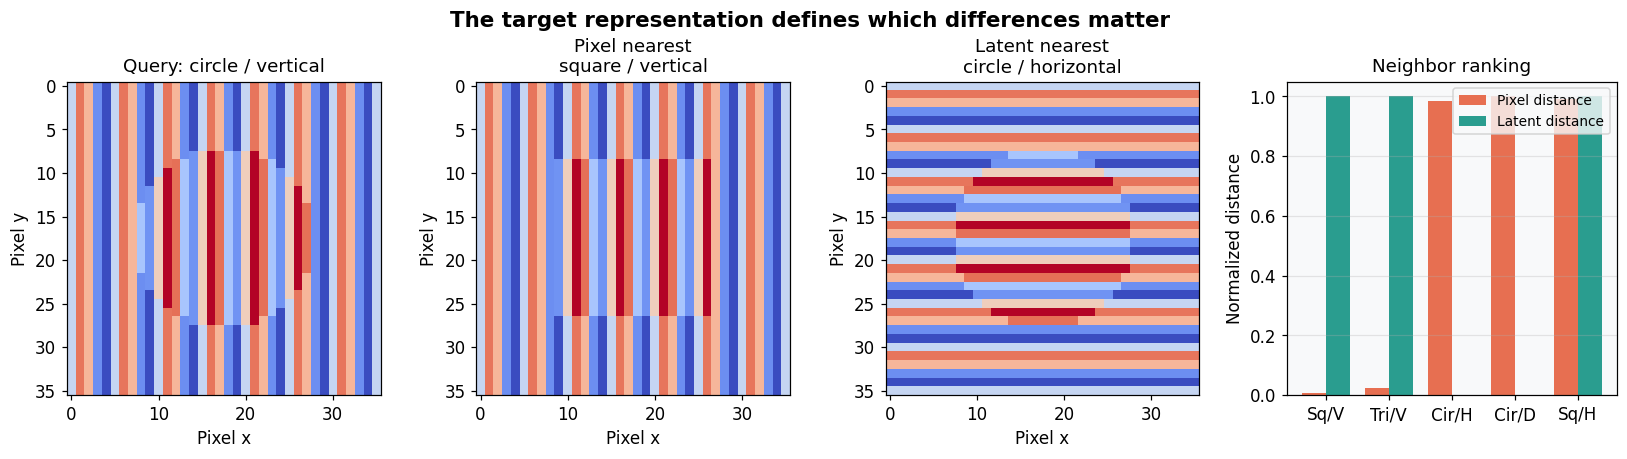

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle('The target representation defines which differences matter', fontsize=14, fontweight='bold')

axes[0].imshow(query_exp3, cmap='coolwarm')
axes[0].set_title('Query: circle / vertical')
axes[1].imshow(candidate_images_exp3[pixel_neighbor_exp3], cmap='coolwarm')
axes[1].set_title(f'Pixel nearest\n{candidate_names_exp3[pixel_neighbor_exp3]}')
axes[2].imshow(candidate_images_exp3[latent_neighbor_exp3], cmap='coolwarm')
axes[2].set_title(f'Latent nearest\n{candidate_names_exp3[latent_neighbor_exp3]}')
for ax in axes[:3]:
    ax.set_xlabel('Pixel x')
    ax.set_ylabel('Pixel y')

indices_exp3 = np.arange(len(candidate_names_exp3))
width_exp3 = 0.38
axes[3].bar(indices_exp3 - width_exp3 / 2, pixel_distances_exp3 / pixel_distances_exp3.max(), width_exp3, label='Pixel distance', color='#e76f51')
axes[3].bar(indices_exp3 + width_exp3 / 2, latent_distances_exp3 / max(latent_distances_exp3.max(), 1), width_exp3, label='Latent distance', color='#2a9d8f')
axes[3].set_xticks(indices_exp3, ['Sq/V', 'Tri/V', 'Cir/H', 'Cir/D', 'Sq/H'])
axes[3].set_ylabel('Normalized distance')
axes[3].set_title('Neighbor ranking')
axes[3].legend(fontsize=9)
axes[3].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Pixel distance retrieves a different shape with matching texture, while semantic latent distance retrieves the same shape with different texture.
2. **Why it looks this way:** High-amplitude texture dominates raw Euclidean distance. The latent metric explicitly weights shape identity and quotients out texture.
3. **Key takeaway:** Better transfer comes from metric alignment, not from latent space containing every observation detail.

---
## Experiment 4: Abstraction improves semantic robustness but loses detail

**Question:** Is more abstraction always better?

Synthetic images combine a low-frequency class pattern with independent high-frequency texture. We vary a Fourier low-pass target from strongly abstract to nearly pixel-complete, then measure few-shot nearest-neighbor classification and observation fidelity.

In [8]:
rng_exp4 = np.random.default_rng(31)
size_exp4 = 28
yy_exp4, xx_exp4 = np.mgrid[:size_exp4, :size_exp4]
x_coord_exp4 = (xx_exp4 - size_exp4 / 2) / size_exp4
y_coord_exp4 = (yy_exp4 - size_exp4 / 2) / size_exp4

def make_dataset_exp4(sample_count):
    labels = rng_exp4.integers(0, 2, size=sample_count)
    images = np.empty((sample_count, size_exp4, size_exp4))
    for index, label in enumerate(labels):
        shift_x, shift_y = rng_exp4.normal(0, 0.04, size=2)
        if label == 0:
            semantic = np.exp(-((x_coord_exp4 - shift_x) ** 2) / 0.025)
        else:
            semantic = np.exp(-((y_coord_exp4 - shift_y) ** 2) / 0.025)
        texture = rng_exp4.normal(0, 0.9, size=(size_exp4, size_exp4))
        texture -= lowpass(texture[None, ...], 0.13)[0]
        images[index] = semantic + texture
    return images, labels

train_images_exp4, train_labels_exp4 = make_dataset_exp4(24)
test_images_exp4, test_labels_exp4 = make_dataset_exp4(240)
cutoffs_exp4 = np.linspace(0.06, 0.70, 15)
accuracy_exp4 = []
fidelity_exp4 = []

for cutoff in cutoffs_exp4:
    train_repr = lowpass(train_images_exp4, cutoff).reshape(len(train_images_exp4), -1)
    test_repr = lowpass(test_images_exp4, cutoff).reshape(len(test_images_exp4), -1)
    distances = np.mean((test_repr[:, None, :] - train_repr[None, :, :]) ** 2, axis=2)
    predictions = train_labels_exp4[np.argmin(distances, axis=1)]
    accuracy_exp4.append(np.mean(predictions == test_labels_exp4))

    reconstructed = lowpass(test_images_exp4, cutoff)
    mse = np.mean((reconstructed - test_images_exp4) ** 2)
    fidelity_exp4.append(1.0 - mse / np.var(test_images_exp4))

abstract_example_exp4 = lowpass(test_images_exp4[:1], cutoffs_exp4[1])[0]
detailed_example_exp4 = lowpass(test_images_exp4[:1], cutoffs_exp4[-2])[0]

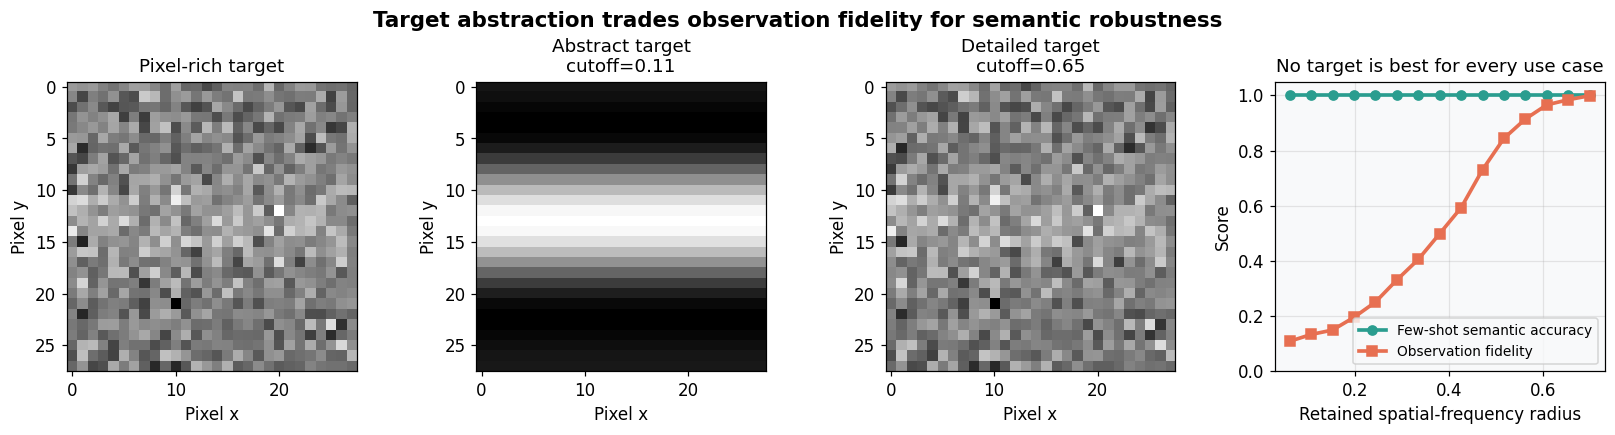

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle('Target abstraction trades observation fidelity for semantic robustness', fontsize=14, fontweight='bold')

axes[0].imshow(test_images_exp4[0], cmap='gray')
axes[0].set_title('Pixel-rich target')
axes[1].imshow(abstract_example_exp4, cmap='gray')
axes[1].set_title(f'Abstract target\ncutoff={cutoffs_exp4[1]:.2f}')
axes[2].imshow(detailed_example_exp4, cmap='gray')
axes[2].set_title(f'Detailed target\ncutoff={cutoffs_exp4[-2]:.2f}')
for ax in axes[:3]:
    ax.set_xlabel('Pixel x')
    ax.set_ylabel('Pixel y')

ax = axes[3]
ax.plot(cutoffs_exp4, accuracy_exp4, marker='o', color='#2a9d8f', linewidth=2.4, label='Few-shot semantic accuracy')
ax.plot(cutoffs_exp4, fidelity_exp4, marker='s', color='#e76f51', linewidth=2.4, label='Observation fidelity')
ax.set_xlabel('Retained spatial-frequency radius')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('No target is best for every use case')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Low-pass targets expose the class structure and suppress random texture; retaining more frequencies improves observation fidelity but can hurt few-shot neighbor geometry.
2. **Why it looks this way:** Extra detail increases information content without guaranteeing that the added dimensions align with the semantic task.
3. **Key takeaway:** The best prediction target depends on whether the system needs transferable semantics, photometric detail, or a deliberate hybrid of both.

---
## Summary / Key Takeaways

| Experiment | Key insight |
|---|---|
| 1. Irreducible nuisance error | Pixel loss pays for unpredictable detail even after semantics are solved. |
| 2. Conditional averaging | MSE can average observation modes that share one semantic representation. |
| 3. Metric alignment | Latent geometry can rank semantic similarity above texture similarity. |
| 4. Abstraction trade-off | Semantic robustness and observation fidelity are competing target priorities. |

### Connection to the broader theory

Latent prediction is advantageous when the target encoder defines the right equivalence classes for the intended downstream tasks. It is not universally more informative than pixels: its power and its failure modes come from choosing what the prediction loss is allowed to ignore.